In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import weibull_min
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# Load data

In [55]:
weather_data = pd.read_csv('weather_madrid_LEMD_1997_2015.csv')

weather_data.head(5)

,CET,Max TemperatureC,Mean TemperatureC,Min TemperatureC,Dew PointC,MeanDew PointC,Min DewpointC,Max Humidity,Mean Humidity,Min Humidity,...,Max VisibilityKm,Mean VisibilityKm,Min VisibilitykM,Max Wind SpeedKm/h,Mean Wind SpeedKm/h,Max Gust SpeedKm/h,Precipitationmm,CloudCover,Events,WindDirDegrees
0,1997-1-1,7.0,4.0,2.0,5.0,3.0,2.0,100.0,95.0,76.0,...,10.0,9.0,4.0,13,6,NaN,0.0,6.0,NaN,229
1,1997-1-2,7.0,3.0,0.0,6.0,3.0,0.0,100.0,92.0,71.0,...,10.0,9.0,4.0,26,8,47.0,0.0,5.0,Rain,143
2,1997-1-3,5.0,3.0,2.0,5.0,1.0,-1.0,100.0,85.0,70.0,...,10.0,10.0,7.0,27,19,NaN,0.0,6.0,Rain-Snow,256
3,1997-1-4,7.0,3.0,-1.0,-2.0,-3.0,-4.0,86.0,63.0,49.0,...,10.0,10.0,10.0,27,19,40.0,0.0,2.0,NaN,284
4,1997-1-5,2.0,0.0,-1.0,2.0,0.0,-3.0,100.0,95.0,86.0,...,10.0,5.0,1.0,14,6,NaN,0.0,7.0,Snow,2


# Data preparation

fill NA

In [56]:
weather_data['CET'] = pd.to_datetime(weather_data['CET'], format='%Y-%m-%d')

In [57]:
# 获取每一列的数据类型
column_types = weather_data.dtypes.to_dict()

# 打印每一列的名称和对应的数据类型
for column, data_type in column_types.items():
    print(f"Column '{column}': {data_type}")

Column 'CET': datetime64[ns]
Column 'Max TemperatureC': float64
Column 'Mean TemperatureC': float64
Column 'Min TemperatureC': float64
Column 'Dew PointC': float64
Column 'MeanDew PointC': float64
Column 'Min DewpointC': float64
Column 'Max Humidity': float64
Column ' Mean Humidity': float64
Column ' Min Humidity': float64
Column ' Max Sea Level PressurehPa': int64
Column ' Mean Sea Level PressurehPa': int64
Column ' Min Sea Level PressurehPa': int64
Column ' Max VisibilityKm': float64
Column ' Mean VisibilityKm': float64
Column ' Min VisibilitykM': float64
Column ' Max Wind SpeedKm/h': int64
Column ' Mean Wind SpeedKm/h': int64
Column ' Max Gust SpeedKm/h': float64
Column 'Precipitationmm': float64
Column ' CloudCover': float64
Column ' Events': object
Column 'WindDirDegrees': int64


In [58]:
def count_empty_value():
    # 计算每一列的缺失值数量
    col_null = weather_data.isnull().sum(axis=0)

    # 统计整个数据集的缺失值数量
    total_null = weather_data.isnull().sum().sum()

    # 打印结果
    print("\nMissing value in each column：\n", col_null.sort_values(ascending=False))


In [59]:
count_empty_value()


Missing value in each column：
  Events                        5014
 Max Gust SpeedKm/h            3306
 CloudCover                    1372
 Min VisibilitykM               940
 Max VisibilityKm               940
 Mean VisibilityKm              940
Mean TemperatureC                 3
 Mean Humidity                    2
Min TemperatureC                  2
Dew PointC                        2
MeanDew PointC                    2
Min DewpointC                     2
Max Humidity                      2
 Min Humidity                     2
Max TemperatureC                  2
CET                               0
Precipitationmm                   0
 Mean Sea Level PressurehPa       0
 Mean Wind SpeedKm/h              0
 Max Wind SpeedKm/h               0
 Min Sea Level PressurehPa        0
 Max Sea Level PressurehPa        0
WindDirDegrees                    0
dtype: int64


In [60]:
# fill events empty values
weather_data[' Events'].fillna('Sunny', inplace=True)

# fill max gust empty values
weather_data[' Max Gust SpeedKm/h'].fillna(0, inplace=True)

In [61]:
print(weather_data[' Max VisibilityKm'].mean())
print(weather_data[' Max VisibilityKm'].max())
print(weather_data[' Min VisibilitykM'].mean())
print(weather_data[' CloudCover'].mean())

14.64407356948229
31.0
9.134877384196185
3.2060661764705882


In [62]:
# fill max visb empty values
weather_data[' Max VisibilityKm'].fillna(14, inplace=True)
# fill min visb empty values
weather_data[' Min VisibilitykM'].fillna(9, inplace=True)
# fill cloudcover empty values
weather_data[' CloudCover'].fillna(3, inplace=True)
# fill mean visb empty values
weather_data[' Mean VisibilityKm'].fillna(11, inplace=True)

In [63]:
weather_data.dropna(inplace=True)


Replace wind dir

In [64]:
# 将小于等于 0 的值替换为 0
weather_data['WindDirDegrees'] = weather_data['WindDirDegrees'].apply(lambda x: max(x, 0))

# 将大于等于 360 的值替换为 360
weather_data['WindDirDegrees'] = weather_data['WindDirDegrees'].apply(lambda x: min(x, 360))

Dummy data

In [65]:
# 获取不同的值
unique_events = weather_data[' Events'].unique()

# 打印不同的值
print("Unique value:", unique_events)
print("There're", len(unique_events), "types class.")

Unique value: ['Sunny' 'Rain' 'Rain-Snow' 'Snow' 'Fog' 'Fog-Rain' 'Rain-Thunderstorm'
 'Thunderstorm' 'Rain-Hail-Thunderstorm' 'Fog-Thunderstorm' 'Tornado'
 'Fog-Rain-Thunderstorm' 'Fog-Rain-Snow' 'Fog-Snow'
 'Rain-Snow-Thunderstorm' 'Rain-Hail']
There're 16 types class.


In [66]:
# 使用 factorize() 函数将 'Events' 列转换为数字
weather_data['Event_Code'] = weather_data[' Events'].factorize()[0]

# 打印结果
print(weather_data[[' Events', 'Event_Code']].drop_duplicates())

                      Events  Event_Code
0                      Sunny           0
1                       Rain           1
2                  Rain-Snow           2
4                       Snow           3
10                       Fog           4
32                  Fog-Rain           5
106        Rain-Thunderstorm           6
209             Thunderstorm           7
464   Rain-Hail-Thunderstorm           8
500         Fog-Thunderstorm           9
1612                 Tornado          10
1764   Fog-Rain-Thunderstorm          11
4237           Fog-Rain-Snow          12
4264                Fog-Snow          13
5048  Rain-Snow-Thunderstorm          14
6523               Rain-Hail          15


# Feature Eng

In [67]:
weather_data = weather_data.drop(columns=[' Events'])

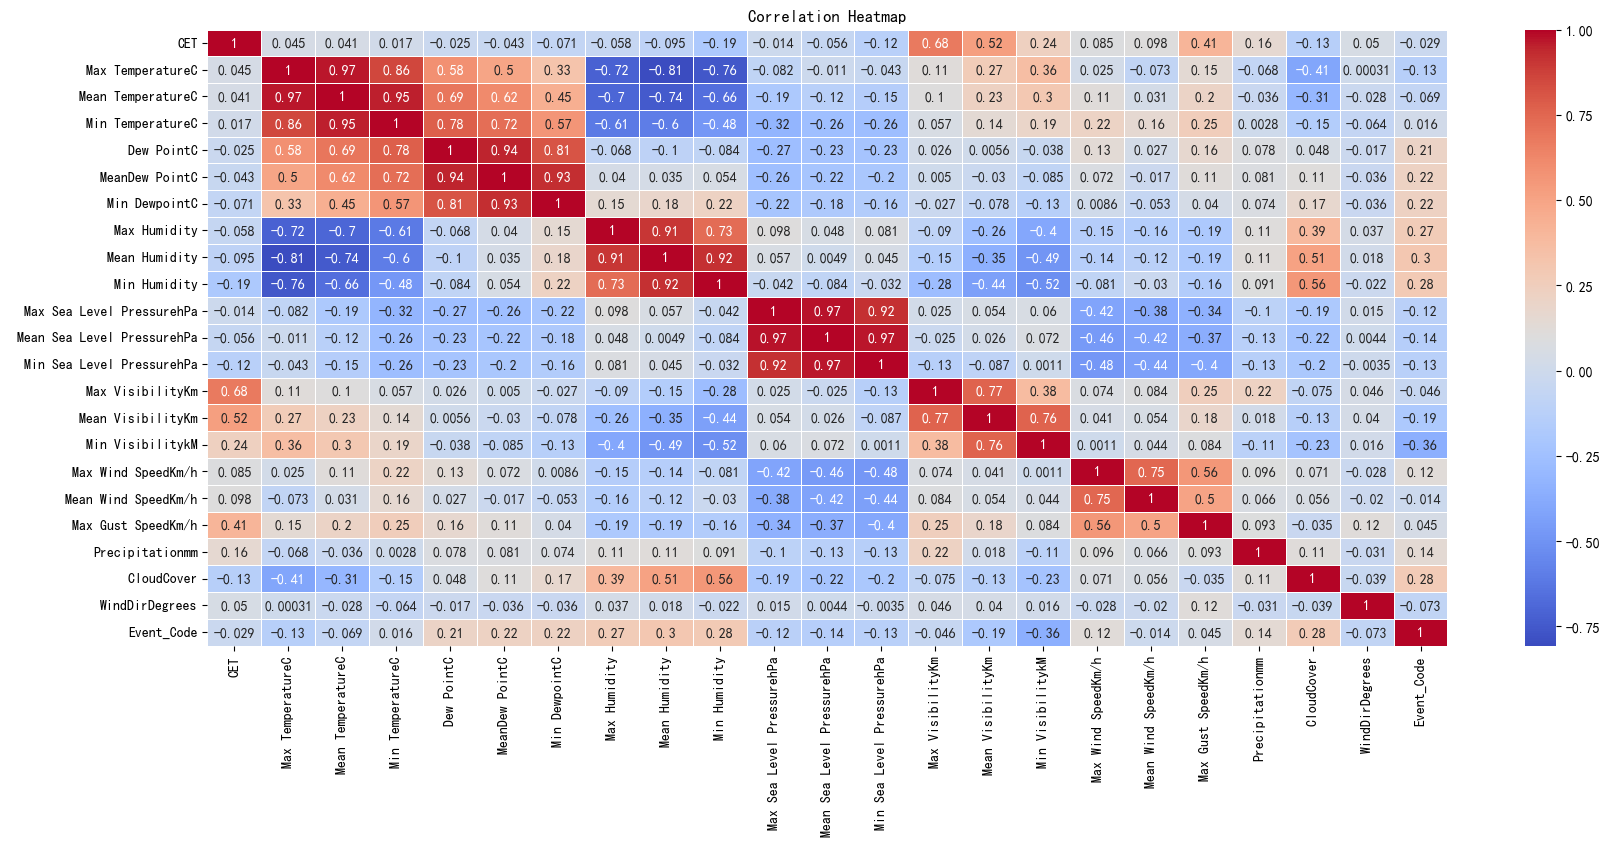

In [68]:
correlation_matrix = weather_data.corr()

# 绘制热力图
plt.figure(figsize=(20, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [69]:
weather = weather_data[['Dew PointC', 'MeanDew PointC','Min DewpointC', 'Max Humidity', ' Mean Humidity', ' Min Humidity', 
' CloudCover', 'Mean TemperatureC']]


In [70]:
season_dict = {
    1: 1, 2: 1, 3: 2,  # Winter
    4: 2, 5: 2, 6: 3,  # Spring
    7: 3, 8: 3, 9: 3,  # Summer
    10: 4, 11: 4, 12: 1  # Fall
}

# 提取月份并映射到季节
weather['Month'] = pd.to_datetime(weather_data['CET']).dt.month
weather['Season'] = weather['Month'].map(season_dict)
weather.drop(columns=['Month'])

C:\Users\fhuur\AppData\Local\Temp\ipykernel_7452\1650531001.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather['Month'] = pd.to_datetime(weather_data['CET']).dt.month
C:\Users\fhuur\AppData\Local\Temp\ipykernel_7452\1650531001.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather['Season'] = weather['Month'].map(season_dict)


,Dew PointC,MeanDew PointC,Min DewpointC,Max Humidity,Mean Humidity,Min Humidity,CloudCover,Mean TemperatureC,Season
0,5.0,3.0,2.0,100.0,95.0,76.0,6.0,4.0,1
1,6.0,3.0,0.0,100.0,92.0,71.0,5.0,3.0,1
2,5.0,1.0,-1.0,100.0,85.0,70.0,6.0,3.0,1
3,-2.0,-3.0,-4.0,86.0,63.0,49.0,2.0,3.0,1
4,2.0,0.0,-3.0,100.0,95.0,86.0,7.0,0.0,1
...,...,...,...,...,...,...,...,...,...
6807,6.0,2.0,-2.0,100.0,77.0,30.0,8.0,7.0,1
6808,8.0,4.0,1.0,100.0,78.0,34.0,7.0,8.0,1
6809,9.0,7.0,5.0,100.0,89.0,66.0,5.0,8.0,1
6810,7.0,6.0,5.0,93.0,87.0,70.0,6.0,8.0,1


In [71]:
correlation = weather[['Season', 'Mean TemperatureC']].corr().iloc[0, 1]
print(f"Correlation between Season and Mean TemperatureC: {correlation:.2f}")


Correlation between Season and Mean TemperatureC: 0.52


In [72]:
weather.drop(columns=['Month'], inplace=True)

C:\Users\fhuur\AppData\Local\Temp\ipykernel_7452\121363912.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather.drop(columns=['Month'], inplace=True)


# Model & Analysis

In [73]:
# Assuming 'WSP125' is the target variable and other columns are features
X = weather.drop(columns=['Mean TemperatureC'])
y = weather['Mean TemperatureC']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize multiple regression models
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(),
    'Ridge Regression': Ridge(),
    'Random Forest Regression': RandomForestRegressor(),
}

# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    predictions = model.predict(X_test)

    # Calculate Mean Squared Error
    mse = mean_squared_error(y_test, predictions)
    print(f"\nModel: {name}")
    print(f"Mean Squared Error: {mse}")

    # Calculate R-squared
    r2 = r2_score(y_test, predictions)
    print(f"R-squared: {r2}")



Model: Linear Regression
Mean Squared Error: 1.7624509559888777
R-squared: 0.9696575134803868

Model: Lasso Regression
Mean Squared Error: 1.8247852057985943
R-squared: 0.9685843624073684

Model: Ridge Regression
Mean Squared Error: 1.7624466173839055
R-squared: 0.9696575881741321

Model: Random Forest Regression
Mean Squared Error: 0.8203481828193833
R-squared: 0.985876824774043


In [74]:
for name, model in models.items():
    # Compute cross-validation scores
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
    
    # Convert negative MSE to positive
    cv_scores_positive = -cv_scores
    
    # Calculate mean and standard deviation of CV scores
    mean_cv_score = cv_scores_positive.mean()
    std_cv_score = cv_scores_positive.std()

    print(f"\nModel: {name}")
    print(f"Mean Cross-Validation MSE: {mean_cv_score:.2f}")
    print(f"Standard Deviation of Cross-Validation MSE: {std_cv_score:.2f}")



Model: Linear Regression
Mean Cross-Validation MSE: 1.80
Standard Deviation of Cross-Validation MSE: 0.28

Model: Lasso Regression
Mean Cross-Validation MSE: 1.84
Standard Deviation of Cross-Validation MSE: 0.27

Model: Ridge Regression
Mean Cross-Validation MSE: 1.80
Standard Deviation of Cross-Validation MSE: 0.28

Model: Random Forest Regression
Mean Cross-Validation MSE: 1.08
Standard Deviation of Cross-Validation MSE: 0.52


# Fine tune

In [75]:
# 假设您的数据框名为 weather
column_names = weather.columns
print(column_names)


Index(['Dew PointC', 'MeanDew PointC', 'Min DewpointC', 'Max Humidity',
       ' Mean Humidity', ' Min Humidity', ' CloudCover', 'Mean TemperatureC',
       'Season'],
      dtype='object')


In [76]:
# plan to only use mean value
weather.drop(columns=['Dew PointC', 'Min DewpointC', 'Max Humidity',
       ' Min Humidity'], inplace=True)

C:\Users\fhuur\AppData\Local\Temp\ipykernel_7452\26470590.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather.drop(columns=['Dew PointC', 'Min DewpointC', 'Max Humidity',


<Axes: >

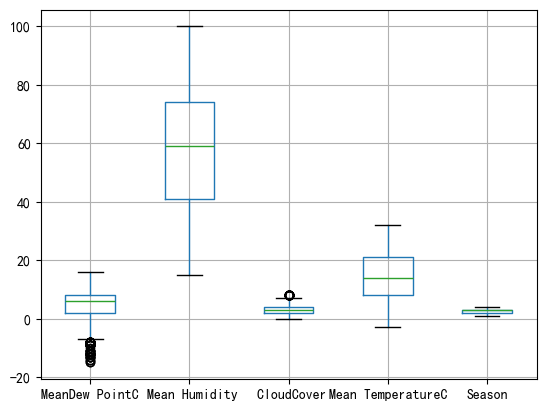

In [77]:
weather.boxplot()

In [78]:
# Assuming 'WSP125' is the target variable and other columns are features
X = weather.drop(columns=['Mean TemperatureC'])
y = weather['Mean TemperatureC']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize multiple regression models
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(),
    'Ridge Regression': Ridge(),
    'Random Forest Regression': RandomForestRegressor(),
}

# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions on the test set
    predictions = model.predict(X_test)

    # Calculate Mean Squared Error
    mse = mean_squared_error(y_test, predictions)
    print(f"\nModel: {name}")
    print(f"Mean Squared Error: {mse}")

    # Calculate R-squared
    r2 = r2_score(y_test, predictions)
    print(f"R-squared: {r2}")



Model: Linear Regression
Mean Squared Error: 2.19104778858807
R-squared: 0.9622787585872083

Model: Lasso Regression
Mean Squared Error: 2.272596592828612
R-squared: 0.9608748083184356

Model: Ridge Regression
Mean Squared Error: 2.1910496982512777
R-squared: 0.9622787257103047

Model: Random Forest Regression
Mean Squared Error: 1.1335436552326956
R-squared: 0.9804848282663314


In [79]:
for name, model in models.items():
    # Compute cross-validation scores
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
    
    # Convert negative MSE to positive
    cv_scores_positive = -cv_scores
    
    # Calculate mean and standard deviation of CV scores
    mean_cv_score = cv_scores_positive.mean()
    std_cv_score = cv_scores_positive.std()

    print(f"\nModel: {name}")
    print(f"Mean Cross-Validation MSE: {mean_cv_score:.2f}")
    print(f"Standard Deviation of Cross-Validation MSE: {std_cv_score:.2f}")



Model: Linear Regression
Mean Cross-Validation MSE: 2.12
Standard Deviation of Cross-Validation MSE: 0.26

Model: Lasso Regression
Mean Cross-Validation MSE: 2.18
Standard Deviation of Cross-Validation MSE: 0.29

Model: Ridge Regression
Mean Cross-Validation MSE: 2.12
Standard Deviation of Cross-Validation MSE: 0.26

Model: Random Forest Regression
Mean Cross-Validation MSE: 1.25
Standard Deviation of Cross-Validation MSE: 0.18


Random forest is the best model in this question.